# Proof of Concept with OpenCV 01

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import itertools as it

In [2]:
def show_image(image):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.show()

## Load Image

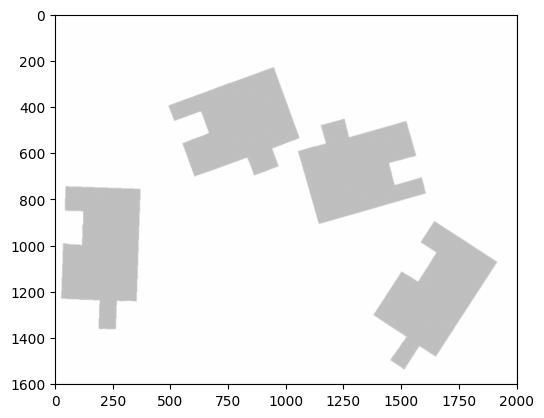

In [3]:
image = cv2.imread("../assets/puzzle_images/simulator_01.png")
show_image(image)

## Object Detection

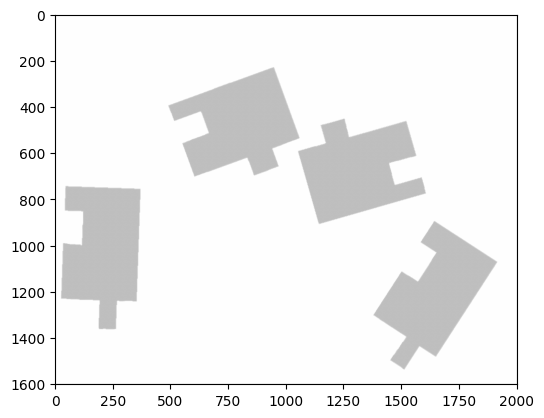

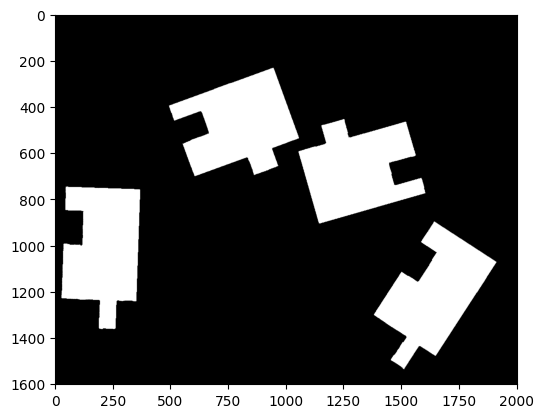

In [32]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
show_image(gray_image)

_, thresh = cv2.threshold(gray_image, 200, 255, cv2.THRESH_BINARY_INV)
show_image(thresh)

In [33]:
def draw_bounding_boxes(image, boxes):
    image = np.copy(image)

    for box in boxes:
        x1, y1, x2, y2 = [int(coord) for coord in box]
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 10)

    return image

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

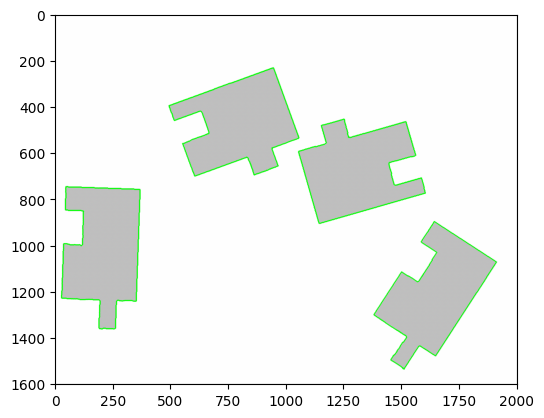

In [34]:
pieces_image = image.copy()
pieces_image = cv2.drawContours(pieces_image, contours, -1, (0, 255, 0), 3)

show_image(pieces_image)

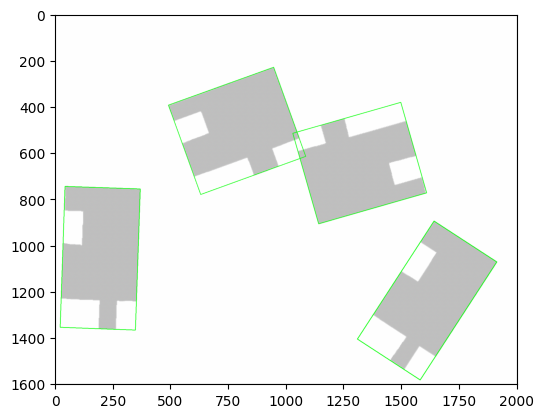

In [35]:
pieces_image = image.copy()
pieces = []

for i, c in enumerate(contours):
    rect = cv2.minAreaRect(c)
    box = cv2.boxPoints(rect).astype(np.float32)

    # Compute width and height from the box
    w = int(np.linalg.norm(box[1] - box[0]))
    h = int(np.linalg.norm(box[2] - box[1]))

    # Define the destination points for a straight rectangle
    dst_pts = np.array([
        [0, 0],
        [w - 1, 0],
        [w - 1, h - 1],
        [0, h - 1]
    ], dtype=np.float32)

    # Perspective transform matrix
    M = cv2.getPerspectiveTransform(box, dst_pts)

    # Warp (crop) the rotated piece
    cropped = cv2.warpPerspective(thresh, M, (w, h))
    pieces.append(cropped)

    # Draw contour box on visualization image
    cv2.drawContours(pieces_image, [box.astype(int)], 0, (0, 255, 0), 2)

show_image(pieces_image)

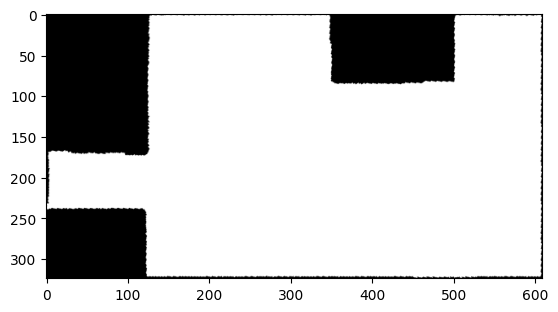

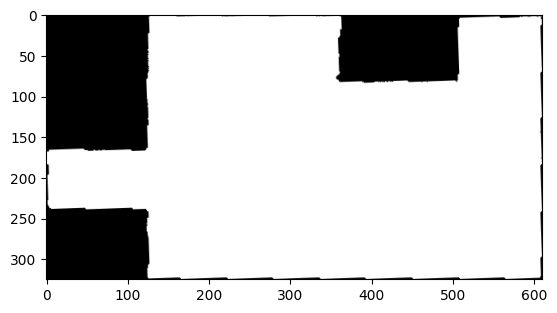

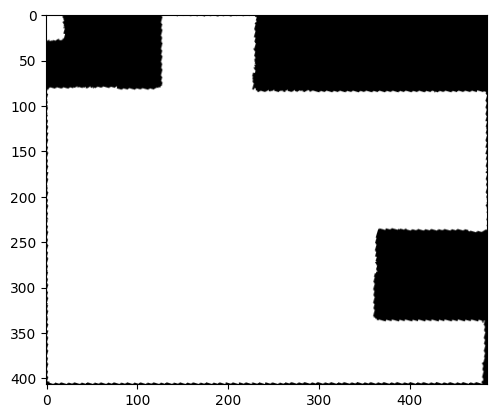

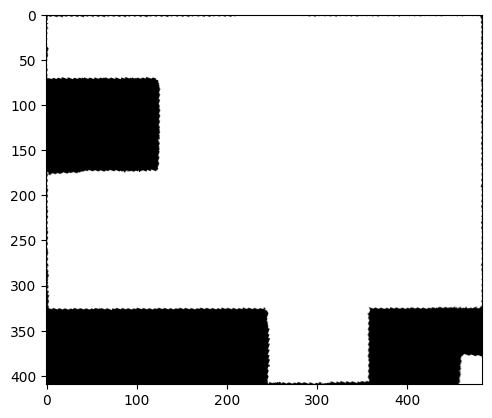

In [36]:
for p in pieces:
    show_image(p)

In [ ]:
# TODO: Mask out the piece by largest white area. The small overlaps in the edges need to go.
# https://stackoverflow.com/questions/44588279/find-and-draw-the-largest-contour-in-opencv-on-a-specific-color-python

## Corner Detection

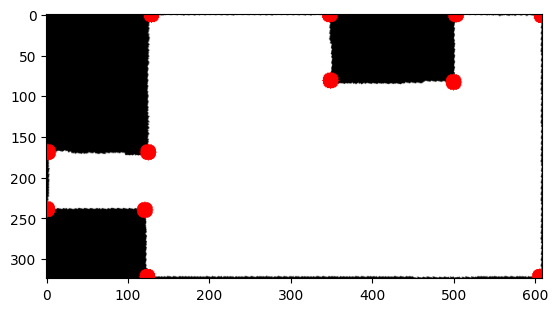

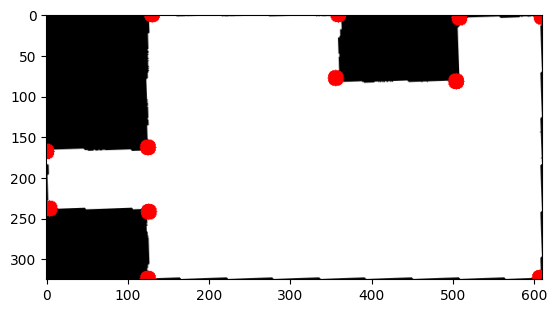

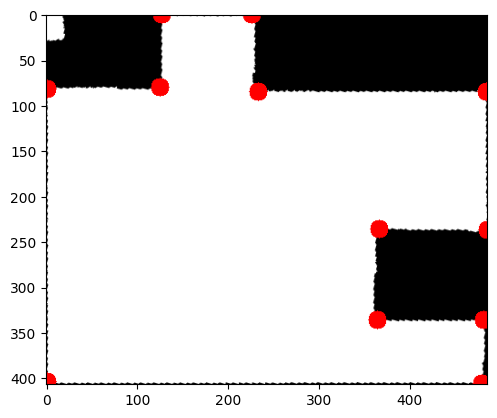

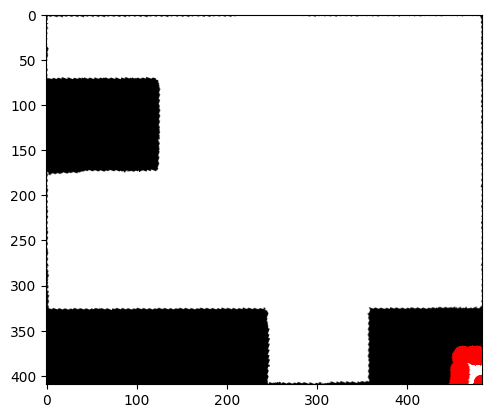

In [38]:
for p in pieces:
    piece_contour, _ = cv2.findContours(p, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    piece_contour = piece_contour[0]

    epsilon = 0.01 * cv2.arcLength(piece_contour, True)
    approx = cv2.approxPolyDP(piece_contour, epsilon, True)

    corners = []
    example_piece_image = cv2.cvtColor(p.copy(), cv2.COLOR_GRAY2RGB)
    for (x, y) in approx.reshape(-1, 2):
        corners.append((x, y))
        cv2.circle(example_piece_image, (x, y), 10, (0, 0, 255), -1)

    show_image(example_piece_image)

## Detecting the 4 Piece Corners

This is not _yet_ working reliably...

IDEA: Maybe select the edges which are closest to the image borders AND are the furthest apart.

In [39]:
# Corresponds to euclidian distance
def distance(p1, p2):
    return np.linalg.norm(np.array(p1)-np.array(p2))

distances = []
for p1, p2 in it.combinations(corners, 2):
    dist = distance(p1, p2)
    distances.append((p1, p2, dist))

distances.sort(key=lambda v: v[2], reverse=True)
distances

[((np.int32(456), np.int32(409)),
  (np.int32(483), np.int32(378)),
  np.float64(41.10960958218893)),
 ((np.int32(456), np.int32(409)),
  (np.int32(481), np.int32(379)),
  np.float64(39.05124837953327)),
 ((np.int32(461), np.int32(377)),
  (np.int32(483), np.int32(409)),
  np.float64(38.8329756778952)),
 ((np.int32(458), np.int32(407)),
  (np.int32(483), np.int32(378)),
  np.float64(38.28837943815329)),
 ((np.int32(456), np.int32(409)),
  (np.int32(477), np.int32(377)),
  np.float64(38.27531841800928)),
 ((np.int32(459), np.int32(380)),
  (np.int32(483), np.int32(409)),
  np.float64(37.64306044943742)),
 ((np.int32(458), np.int32(407)),
  (np.int32(481), np.int32(379)),
  np.float64(36.235341863986875)),
 ((np.int32(457), np.int32(403)),
  (np.int32(483), np.int32(378)),
  np.float64(36.069377593742864)),
 ((np.int32(456), np.int32(409)),
  (np.int32(472), np.int32(377)),
  np.float64(35.77708763999664)),
 ((np.int32(458), np.int32(407)),
  (np.int32(477), np.int32(377)),
  np.float64(

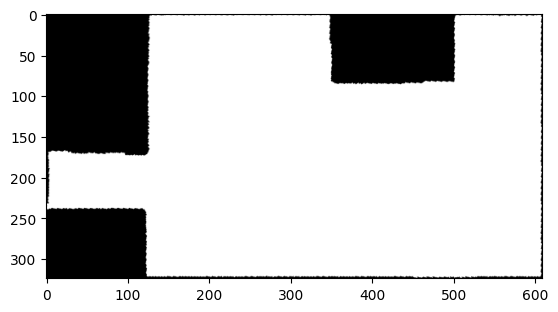

In [41]:
# Assumes all corners were detected (RISK)
# THIS IS WRONG
diag1 = distances[0]
diag2 = distances[1]

len1 = distances[2]
len2 = distances[3]
wid1 = distances[4]
wid2 = distances[5]

# Here we could test if the detected corners touch each other

example_piece_image = cv2.cvtColor(pieces[0].copy(), cv2.COLOR_GRAY2RGB)
cv2.circle(example_piece_image, wid2[0], 10, (0, 0, 255), -1)
show_image(example_piece_image)